# Stage 2: RF Classifier Metrics Reference
## All 4 Encoders (LNN, LSTM, CNN, BERT) — Seen + Unseen Data

**Purpose**: Consolidated reference file for report writing. Contains full metrics for the **Random Forest** classifier only, across all 4 encoder architectures.

**Metrics included per encoder:**
- Confusion Matrix
- Classification Report (Precision, Recall, F1-Score)
- ROC Curve + AUC
- Per-scenario accuracy breakdown

**Evaluated on:**
1. **Seen (test split)** — 30% held-out from `combined_uwb_dataset.csv` (3 NLOS scenarios)
2. **Unseen (OOD)** — `unseen_dataset.csv` (2 NLOS scenarios never seen during training)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import re
import os
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──
CONFIG = {
    "search_start": 740,
    "search_end": 810,
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "test_ratio": 0.30,
    "seed": 42,
}
np.random.seed(CONFIG["seed"])

---
## 1. Helper Functions (Data Loading + Labeling)

In [19]:
# ==========================================
# ROI ALIGNMENT
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)
    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]
    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val
    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break
    return leading_edge


def count_peaks_in_roi(sig, leading_edge, config=CONFIG):
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0
    roi_norm = roi / np.max(roi)
    peaks, _ = find_peaks(roi_norm, prominence=config["peak_prominence"],
                          distance=config["peak_min_distance"])
    return len(peaks)


def compute_bounce_dominance(sig, leading_edge, bounce_path_idx,
                              window=CONFIG["bounce_search_window"]):
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0.0
    strongest_amp = float(np.max(roi))
    bounce_idx = int(round(bounce_path_idx))
    b_start = max(0, bounce_idx - window)
    b_end = min(len(sig), bounce_idx + window + 1)
    if b_start >= b_end:
        return 0.0
    bounce_amp = float(np.max(sig[b_start:b_end]))
    return bounce_amp / strongest_amp


def get_strongest_peak_power(sig, leading_edge):
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    return float(np.max(roi)) if len(roi) > 0 else 0.0


def load_nlos_features(filepath):
    """Load NLOS samples and compute mixture quality labels."""
    df = pd.read_csv(filepath)
    nlos_df = df[df["Label"] == 1].copy().reset_index(drop=True)
    
    cir_cols = sorted([c for c in nlos_df.columns if re.match(r'^CIR_?\d+$', c)],
                      key=lambda c: int(re.search(r'\d+', c).group()))
    raw_sigs, leading_edges = [], []
    quality_labels, num_peaks_arr, bounce_dom_arr, spp_arr = [], [], [], []
    
    for i in range(len(nlos_df)):
        row = nlos_df.iloc[i]
        sig = row[cir_cols].values.astype(float)
        rxpacc = row.get("RXPACC", 1.0)
        if rxpacc > 0:
            sig = sig / rxpacc
        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)
        
        bounce_path_idx = row.get("bounce_path_idx", le)
        bd = compute_bounce_dominance(sig, le, bounce_path_idx)
        np_count = count_peaks_in_roi(sig, le)
        spp = get_strongest_peak_power(sig, le)
        
        bounce_dom_arr.append(bd)
        num_peaks_arr.append(np_count)
        spp_arr.append(spp)
        
        if bd >= CONFIG["dominance_threshold"] and np_count <= CONFIG["dominant_path_max_peaks"]:
            quality_labels.append(0)  # Correctable
        else:
            quality_labels.append(1)  # Challenging
    
    return (np.array(raw_sigs), np.array(leading_edges), nlos_df,
            np.array(quality_labels), np.array(num_peaks_arr),
            np.array(bounce_dom_arr), np.array(spp_arr))


def preprocess_cir(sig, leading_edge, total_len, pre_crop):
    """Generic CIR preprocessing: crop window + min-max normalize."""
    start = max(0, leading_edge - pre_crop)
    end = start + total_len
    if end > len(sig):
        end = len(sig)
        start = max(0, end - total_len)
    crop = sig[start:end]
    if len(crop) < total_len:
        crop = np.pad(crop, (0, total_len - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(total_len)
    return crop


print("Helper functions loaded.")

Helper functions loaded.


---
## 2. Load Data + Pre-saved Embeddings from Each Encoder's Stage 2 Notebook

In [20]:
# ==========================================
# LOAD SEEN + UNSEEN DATA
# ==========================================
seen_path = "dataset/channels/combined_uwb_dataset.csv"
unseen_path = "dataset/channels/unseen_dataset.csv"

(raw_sigs, leading_edges, nlos_df, quality_labels,
 num_peaks, bounce_dom, spp) = load_nlos_features(seen_path)

(unseen_raw_sigs, unseen_leading_edges, unseen_nlos_df, unseen_labels,
 unseen_num_peaks, unseen_bounce_dom, unseen_spp) = load_nlos_features(unseen_path)

# Scenario labels
scenario_labels = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in nlos_df['Source_File'].values
])
unseen_scenarios = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in unseen_nlos_df['Source_File'].values
])

print(f"Seen NLOS: {len(quality_labels)} (Corr={int(np.sum(quality_labels==0))}, Chal={int(np.sum(quality_labels==1))})")
print(f"Unseen NLOS: {len(unseen_labels)} (Corr={int(np.sum(unseen_labels==0))}, Chal={int(np.sum(unseen_labels==1))})")
print(f"Seen scenarios: {sorted(set(scenario_labels), key=lambda x: float(x.replace('m','')))}")
print(f"Unseen scenarios: {sorted(set(unseen_scenarios), key=lambda x: float(x.replace('m','')))}")

Seen NLOS: 1800 (Corr=506, Chal=1294)
Unseen NLOS: 1200 (Corr=406, Chal=794)
Seen scenarios: [np.str_('9.54m'), np.str_('16.09m'), np.str_('16.80m')]
Unseen scenarios: [np.str_('8.91m'), np.str_('12.79m')]


In [21]:
# ==========================================
# LOAD PRE-SAVED EMBEDDINGS FROM EACH ENCODER'S STAGE 2 NOTEBOOK
# ==========================================
# These .npy files are saved by each encoder's stage2_bounce_classifier.ipynb
# to ensure exact reproducibility (avoids GPU non-determinism on re-extraction).

ENCODER_DIRS = {
    "LNN":  "lnn",
    "LSTM": "lstm",
    "CNN":  "cnn",
    "BERT": "bert",
}

all_data = {}

for name, enc_dir in ENCODER_DIRS.items():
    seen_emb = np.load(f"{enc_dir}/stage2_seen_embeddings.npy")
    unseen_emb = np.load(f"{enc_dir}/stage2_unseen_embeddings.npy")
    emb_dim = seen_emb.shape[1]

    print(f"{name:>4s}  emb_dim={emb_dim}  seen={seen_emb.shape}  unseen={unseen_emb.shape}")

    all_data[name] = {
        "emb_dim": emb_dim,
        "seen_emb": seen_emb,
        "unseen_emb": unseen_emb,
    }

print(f"\nAll 4 encoders' embeddings loaded from .npy files.")

 LNN  emb_dim=64  seen=(1800, 64)  unseen=(1200, 64)
LSTM  emb_dim=64  seen=(1800, 64)  unseen=(1200, 64)
 CNN  emb_dim=128  seen=(1800, 128)  unseen=(1200, 128)
BERT  emb_dim=64  seen=(1800, 64)  unseen=(1200, 64)

All 4 encoders' embeddings loaded from .npy files.


---
## 4. Train RF on Each Encoder's Embeddings

In [22]:
# ==========================================
# TRAIN RF FOR EACH ENCODER — 70/30 SPLIT
# ==========================================
y_all = quality_labels

# Same split indices for all encoders (same seed + stratification)
idx_all = np.arange(len(y_all))
idx_train, idx_test = train_test_split(
    idx_all, test_size=CONFIG["test_ratio"], stratify=y_all, random_state=CONFIG["seed"]
)
y_train, y_test = y_all[idx_train], y_all[idx_test]
scenario_test = scenario_labels[idx_test]
unique_scenarios = sorted(set(scenario_labels), key=lambda x: float(x.replace('m','')))
unseen_unique_scenarios = sorted(set(unseen_scenarios), key=lambda x: float(x.replace('m','')))

print(f"Split: Train={len(idx_train)}, Test={len(idx_test)}")
print(f"  Train — Corr: {int(np.sum(y_train==0))}, Chal: {int(np.sum(y_train==1))}")
print(f"  Test  — Corr: {int(np.sum(y_test==0))}, Chal: {int(np.sum(y_test==1))}")

# Train & evaluate RF for each encoder
rf_results = {}  # {name: {rf_model, seen_*, unseen_*}}

for name, data in all_data.items():
    X_train = data["seen_emb"][idx_train]
    X_test = data["seen_emb"][idx_test]
    X_unseen = data["unseen_emb"]
    y_unseen = unseen_labels
    
    # Train RF
    rf = RandomForestClassifier(
        n_estimators=CONFIG["n_estimators"], max_depth=CONFIG["max_depth"],
        min_samples_split=CONFIG["min_samples_split"], min_samples_leaf=CONFIG["min_samples_leaf"],
        class_weight="balanced", random_state=CONFIG["seed"], n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    
    # ── SEEN (test split) ──
    y_pred_seen = rf.predict(X_test)
    y_prob_seen = rf.predict_proba(X_test)[:, 1]
    fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_seen)
    auc_s = auc(fpr_s, tpr_s)
    report_s = classification_report(y_test, y_pred_seen,
                                     target_names=['Correctable', 'Challenging'],
                                     output_dict=True)
    cm_s = confusion_matrix(y_test, y_pred_seen)
    prec_s, rec_s, _ = precision_recall_curve(y_test, y_prob_seen)
    ap_s = average_precision_score(y_test, y_prob_seen)
    
    # Per-scenario (seen test)
    per_sc_seen = {}
    for sc in unique_scenarios:
        mask = scenario_test == sc
        if mask.sum() > 0:
            per_sc_seen[sc] = (y_test[mask] == y_pred_seen[mask]).mean()
    
    # ── UNSEEN ──
    y_pred_uns = rf.predict(X_unseen)
    y_prob_uns = rf.predict_proba(X_unseen)[:, 1]
    fpr_u, tpr_u, _ = roc_curve(y_unseen, y_prob_uns)
    auc_u = auc(fpr_u, tpr_u)
    report_u = classification_report(y_unseen, y_pred_uns,
                                     target_names=['Correctable', 'Challenging'],
                                     output_dict=True)
    cm_u = confusion_matrix(y_unseen, y_pred_uns)
    prec_u, rec_u, _ = precision_recall_curve(y_unseen, y_prob_uns)
    ap_u = average_precision_score(y_unseen, y_prob_uns)
    
    # Per-scenario (unseen)
    per_sc_unseen = {}
    for sc in unseen_unique_scenarios:
        mask = unseen_scenarios == sc
        if mask.sum() > 0:
            per_sc_unseen[sc] = (y_unseen[mask] == y_pred_uns[mask]).mean()
    
    rf_results[name] = {
        "rf_model": rf, "emb_dim": data["emb_dim"],
        # Seen
        "seen_pred": y_pred_seen, "seen_prob": y_prob_seen,
        "seen_fpr": fpr_s, "seen_tpr": tpr_s, "seen_auc": auc_s,
        "seen_report": report_s, "seen_cm": cm_s,
        "seen_prec_curve": prec_s, "seen_rec_curve": rec_s, "seen_ap": ap_s,
        "seen_acc": (y_test == y_pred_seen).mean(),
        "seen_per_scenario": per_sc_seen,
        # Unseen
        "unseen_pred": y_pred_uns, "unseen_prob": y_prob_uns,
        "unseen_fpr": fpr_u, "unseen_tpr": tpr_u, "unseen_auc": auc_u,
        "unseen_report": report_u, "unseen_cm": cm_u,
        "unseen_prec_curve": prec_u, "unseen_rec_curve": rec_u, "unseen_ap": ap_u,
        "unseen_acc": (y_unseen == y_pred_uns).mean(),
        "unseen_per_scenario": per_sc_unseen,
    }
    
    print(f"\n{name} ({data['emb_dim']}-dim):")
    print(f"  Seen  — Acc: {100*rf_results[name]['seen_acc']:.2f}%, AUC: {auc_s:.4f}, AP: {ap_s:.4f}")
    print(f"  Unseen — Acc: {100*rf_results[name]['unseen_acc']:.2f}%, AUC: {auc_u:.4f}, AP: {ap_u:.4f}")

Split: Train=1260, Test=540
  Train — Corr: 354, Chal: 906
  Test  — Corr: 152, Chal: 388

LNN (64-dim):
  Seen  — Acc: 93.33%, AUC: 0.9762, AP: 0.9912
  Unseen — Acc: 82.08%, AUC: 0.8641, AP: 0.9112

LSTM (64-dim):
  Seen  — Acc: 93.33%, AUC: 0.9772, AP: 0.9917
  Unseen — Acc: 76.42%, AUC: 0.8795, AP: 0.9312

CNN (128-dim):
  Seen  — Acc: 93.89%, AUC: 0.9817, AP: 0.9934
  Unseen — Acc: 76.42%, AUC: 0.8406, AP: 0.9222

BERT (64-dim):
  Seen  — Acc: 92.41%, AUC: 0.9754, AP: 0.9906
  Unseen — Acc: 71.33%, AUC: 0.8265, AP: 0.9185


---
## 5. Summary Tables

In [23]:
# ==========================================
# SUMMARY TABLES — ALL 4 ENCODERS × RF
# ==========================================
encoder_names = list(rf_results.keys())

# ── Table 1: Overall Metrics ──
print("=" * 100)
print("TABLE 1: Overall Metrics — RF Classifier (Seen vs Unseen)")
print("=" * 100)
print(f"{'Encoder':<8} {'Emb':>4} | {'Seen Acc':>9} {'Seen AUC':>9} {'Seen AP':>8} {'Seen F1m':>9} | {'OOD Acc':>9} {'OOD AUC':>9} {'OOD AP':>8} {'OOD F1m':>9}")
print("-" * 100)
for name in encoder_names:
    r = rf_results[name]
    sf1m = r['seen_report']['macro avg']['f1-score']
    uf1m = r['unseen_report']['macro avg']['f1-score']
    print(f"{name:<8} {r['emb_dim']:>4} | {100*r['seen_acc']:>8.2f}% {r['seen_auc']:>9.4f} {r['seen_ap']:>8.4f} {sf1m:>9.4f} | {100*r['unseen_acc']:>8.2f}% {r['unseen_auc']:>9.4f} {r['unseen_ap']:>8.4f} {uf1m:>9.4f}")

# ── Table 2: Per-Class Metrics (Seen) ──
print(f"\n\n{'='*90}")
print("TABLE 2: Per-Class Metrics — Seen (Test Split)")
print("=" * 90)
print(f"{'Encoder':<8} | {'Corr P':>7} {'Corr R':>7} {'Corr F1':>8} {'Corr N':>6} | {'Chal P':>7} {'Chal R':>7} {'Chal F1':>8} {'Chal N':>6}")
print("-" * 90)
for name in encoder_names:
    r = rf_results[name]['seen_report']
    c, ch = r['Correctable'], r['Challenging']
    print(f"{name:<8} | {c['precision']:>7.4f} {c['recall']:>7.4f} {c['f1-score']:>8.4f} {int(c['support']):>6} | {ch['precision']:>7.4f} {ch['recall']:>7.4f} {ch['f1-score']:>8.4f} {int(ch['support']):>6}")

# ── Table 3: Per-Class Metrics (Unseen) ──
print(f"\n\n{'='*90}")
print("TABLE 3: Per-Class Metrics — Unseen (OOD)")
print("=" * 90)
print(f"{'Encoder':<8} | {'Corr P':>7} {'Corr R':>7} {'Corr F1':>8} {'Corr N':>6} | {'Chal P':>7} {'Chal R':>7} {'Chal F1':>8} {'Chal N':>6}")
print("-" * 90)
for name in encoder_names:
    r = rf_results[name]['unseen_report']
    c, ch = r['Correctable'], r['Challenging']
    print(f"{name:<8} | {c['precision']:>7.4f} {c['recall']:>7.4f} {c['f1-score']:>8.4f} {int(c['support']):>6} | {ch['precision']:>7.4f} {ch['recall']:>7.4f} {ch['f1-score']:>8.4f} {int(ch['support']):>6}")

# ── Table 4: Per-Scenario Accuracy ──
print(f"\n\n{'='*80}")
print("TABLE 4: Per-Scenario Accuracy")
print("=" * 80)
print(f"\n--- Seen (Test Split) ---")
print(f"{'Encoder':<8}" + "".join(f"{sc:>12}" for sc in unique_scenarios))
print("-" * (8 + 12 * len(unique_scenarios)))
for name in encoder_names:
    row = f"{name:<8}"
    for sc in unique_scenarios:
        acc = rf_results[name]['seen_per_scenario'].get(sc, 0)
        row += f"{100*acc:>11.1f}%"
    print(row)

print(f"\n--- Unseen (OOD) ---")
print(f"{'Encoder':<8}" + "".join(f"{sc:>12}" for sc in unseen_unique_scenarios))
print("-" * (8 + 12 * len(unseen_unique_scenarios)))
for name in encoder_names:
    row = f"{name:<8}"
    for sc in unseen_unique_scenarios:
        acc = rf_results[name]['unseen_per_scenario'].get(sc, 0)
        row += f"{100*acc:>11.1f}%"
    print(row)

# ── Table 5: Generalization Gap ──
print(f"\n\n{'='*60}")
print("TABLE 5: Generalization Gap (Seen → Unseen)")
print("=" * 60)
print(f"{'Encoder':<8} {'Seen Acc':>10} {'OOD Acc':>10} {'Gap':>8} {'Seen AUC':>10} {'OOD AUC':>10}")
print("-" * 60)
for name in encoder_names:
    r = rf_results[name]
    gap = r['unseen_acc'] - r['seen_acc']
    print(f"{name:<8} {100*r['seen_acc']:>9.2f}% {100*r['unseen_acc']:>9.2f}% {100*gap:>+7.2f}% {r['seen_auc']:>10.4f} {r['unseen_auc']:>10.4f}")

TABLE 1: Overall Metrics — RF Classifier (Seen vs Unseen)
Encoder   Emb |  Seen Acc  Seen AUC  Seen AP  Seen F1m |   OOD Acc   OOD AUC   OOD AP   OOD F1m
----------------------------------------------------------------------------------------------------
LNN        64 |    93.33%    0.9762   0.9912    0.9176 |    82.08%    0.8641   0.9112    0.7923
LSTM       64 |    93.33%    0.9772   0.9917    0.9189 |    76.42%    0.8795   0.9312    0.6748
CNN       128 |    93.89%    0.9817   0.9934    0.9246 |    76.42%    0.8406   0.9222    0.7029
BERT       64 |    92.41%    0.9754   0.9906    0.9060 |    71.33%    0.8265   0.9185    0.5901


TABLE 2: Per-Class Metrics — Seen (Test Split)
Encoder  |  Corr P  Corr R  Corr F1 Corr N |  Chal P  Chal R  Chal F1 Chal N
------------------------------------------------------------------------------------------
LNN      |  0.8816  0.8816   0.8816    152 |  0.9536  0.9536   0.9536    388
LSTM     |  0.8625  0.9079   0.8846    152 |  0.9632  0.9433   0.95

---
## 6. Confusion Matrices — All Encoders

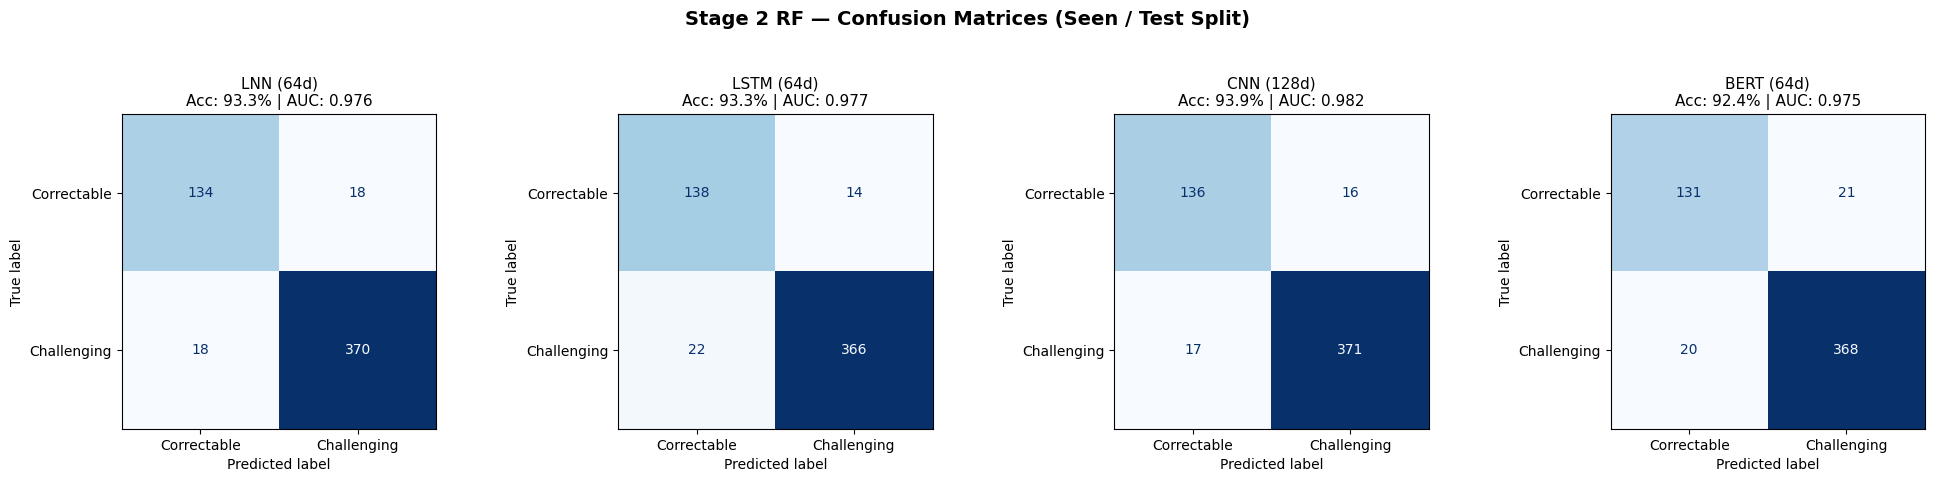

In [24]:
# ==========================================
# CONFUSION MATRICES — SEEN (TEST SPLIT)
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, name in enumerate(encoder_names):
    ax = axs[idx]
    r = rf_results[name]
    disp = ConfusionMatrixDisplay(r['seen_cm'], display_labels=['Correctable', 'Challenging'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name} ({r['emb_dim']}d)\nAcc: {100*r['seen_acc']:.1f}% | AUC: {r['seen_auc']:.3f}", fontsize=11)
plt.suptitle("Stage 2 RF — Confusion Matrices (Seen / Test Split)", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

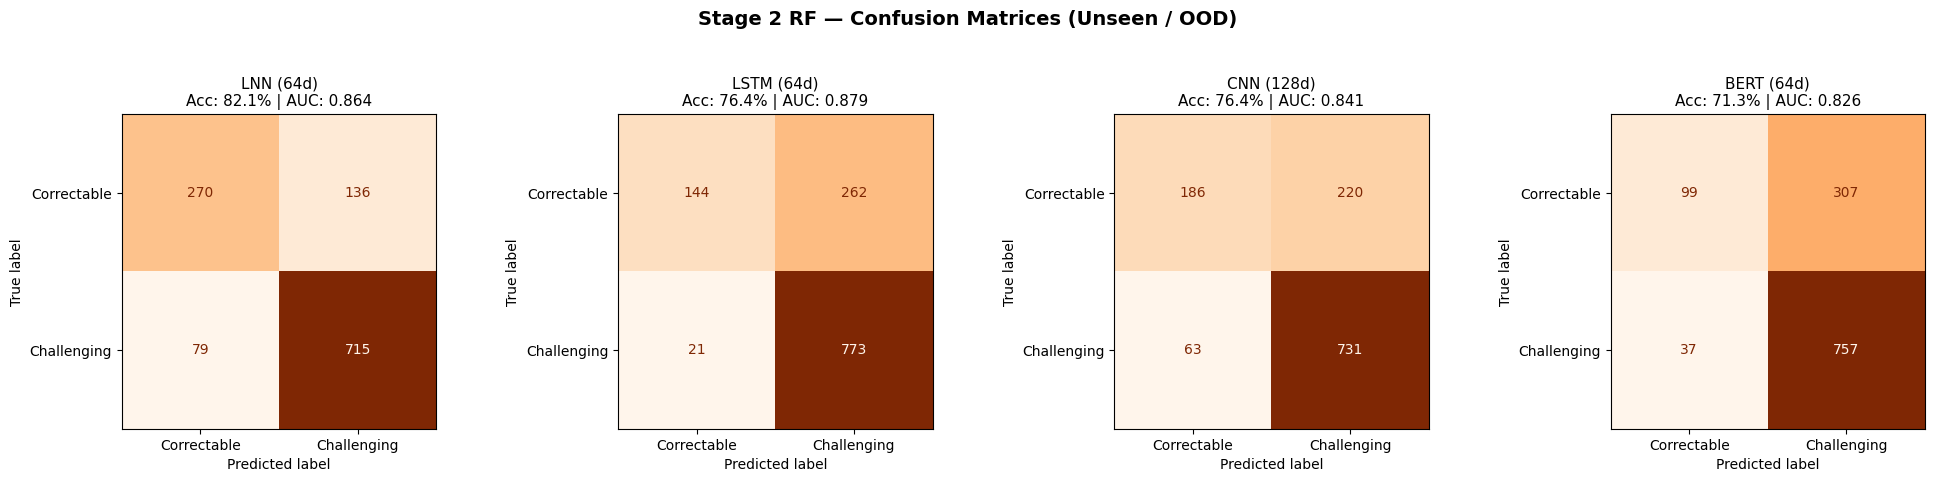

In [25]:
# ==========================================
# CONFUSION MATRICES — UNSEEN (OOD)
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, name in enumerate(encoder_names):
    ax = axs[idx]
    r = rf_results[name]
    disp = ConfusionMatrixDisplay(r['unseen_cm'], display_labels=['Correctable', 'Challenging'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f"{name} ({r['emb_dim']}d)\nAcc: {100*r['unseen_acc']:.1f}% | AUC: {r['unseen_auc']:.3f}", fontsize=11)
plt.suptitle("Stage 2 RF — Confusion Matrices (Unseen / OOD)", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 7. ROC Curves

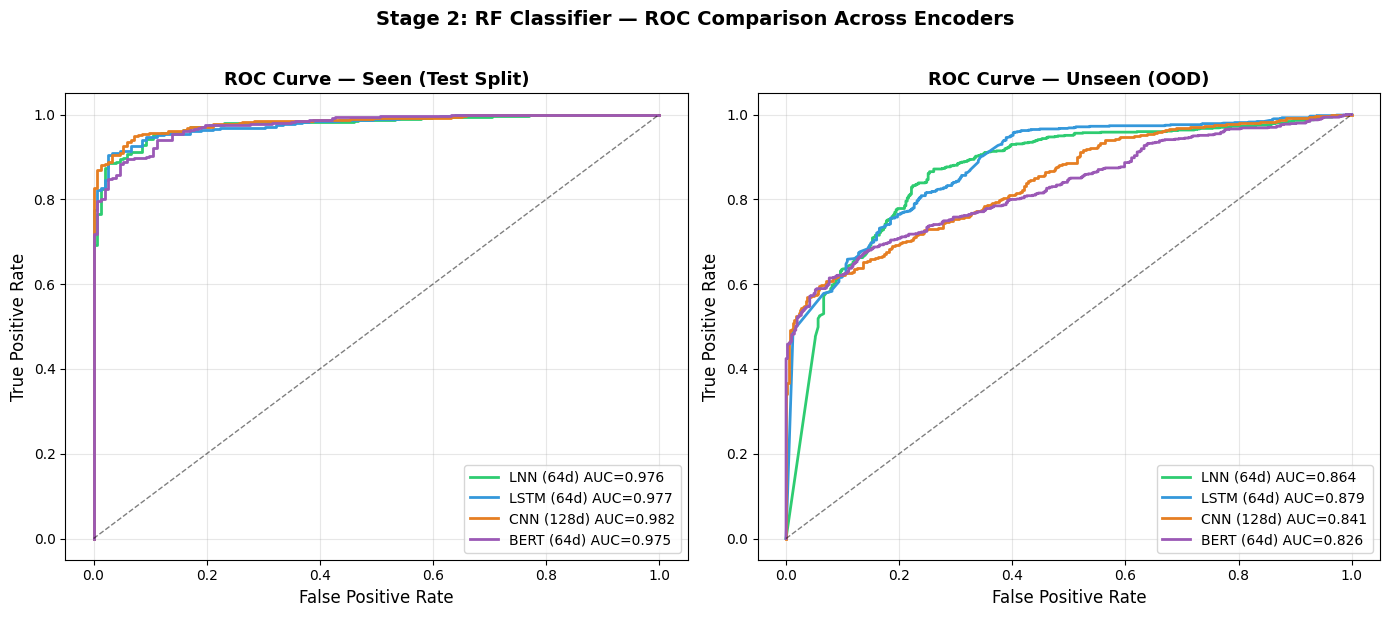

In [26]:
# ==========================================
# ROC CURVES — SEEN vs UNSEEN (side by side)
# ==========================================
colors = {'LNN': '#2ecc71', 'LSTM': '#3498db', 'CNN': '#e67e22', 'BERT': '#9b59b6'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Seen ROC
for name in encoder_names:
    r = rf_results[name]
    ax1.plot(r['seen_fpr'], r['seen_tpr'], color=colors[name], lw=2,
             label=f"{name} ({r['emb_dim']}d) AUC={r['seen_auc']:.3f}")
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve — Seen (Test Split)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Unseen ROC
for name in encoder_names:
    r = rf_results[name]
    ax2.plot(r['unseen_fpr'], r['unseen_tpr'], color=colors[name], lw=2,
             label=f"{name} ({r['emb_dim']}d) AUC={r['unseen_auc']:.3f}")
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve — Unseen (OOD)', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Stage 2: RF Classifier — ROC Comparison Across Encoders',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Precision-Recall Curves

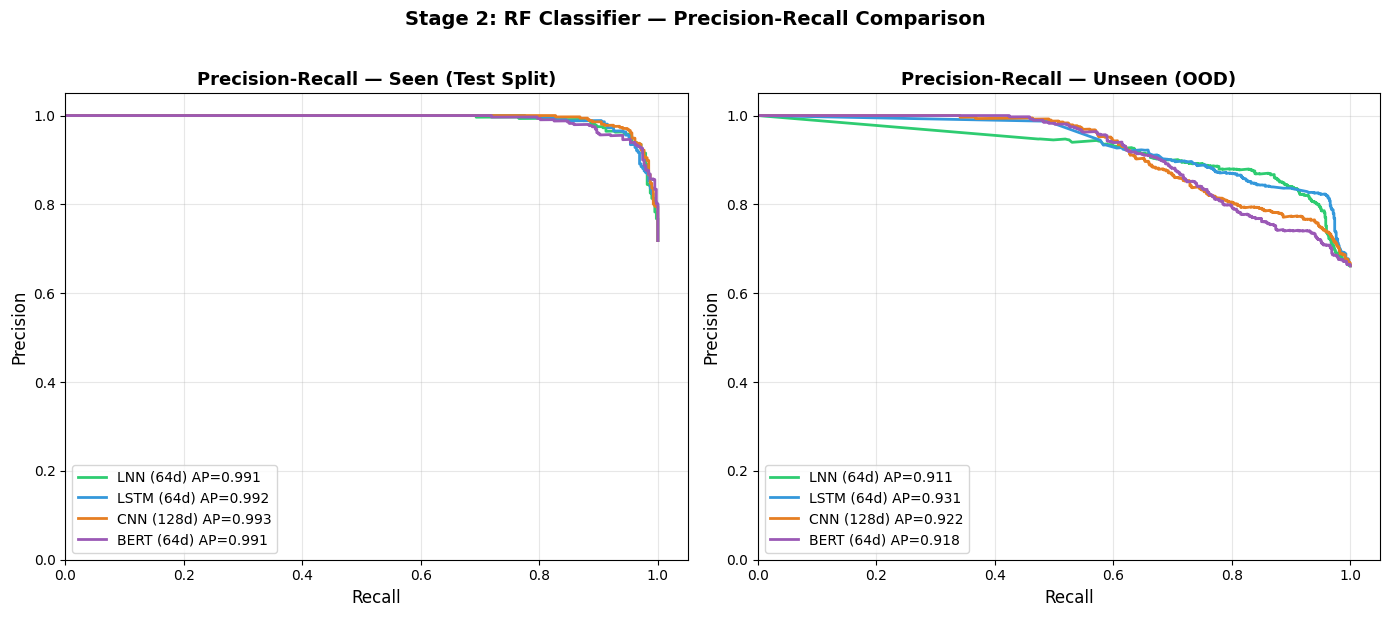

In [27]:
# ==========================================
# PRECISION-RECALL CURVES — SEEN vs UNSEEN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Seen PR
for name in encoder_names:
    r = rf_results[name]
    ax1.plot(r['seen_rec_curve'], r['seen_prec_curve'], color=colors[name], lw=2,
             label=f"{name} ({r['emb_dim']}d) AP={r['seen_ap']:.3f}")
ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall — Seen (Test Split)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1.05])
ax1.set_ylim([0, 1.05])

# Unseen PR
for name in encoder_names:
    r = rf_results[name]
    ax2.plot(r['unseen_rec_curve'], r['unseen_prec_curve'], color=colors[name], lw=2,
             label=f"{name} ({r['emb_dim']}d) AP={r['unseen_ap']:.3f}")
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall — Unseen (OOD)', fontsize=13, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1.05])
ax2.set_ylim([0, 1.05])

plt.suptitle('Stage 2: RF Classifier — Precision-Recall Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Bar Chart Comparisons

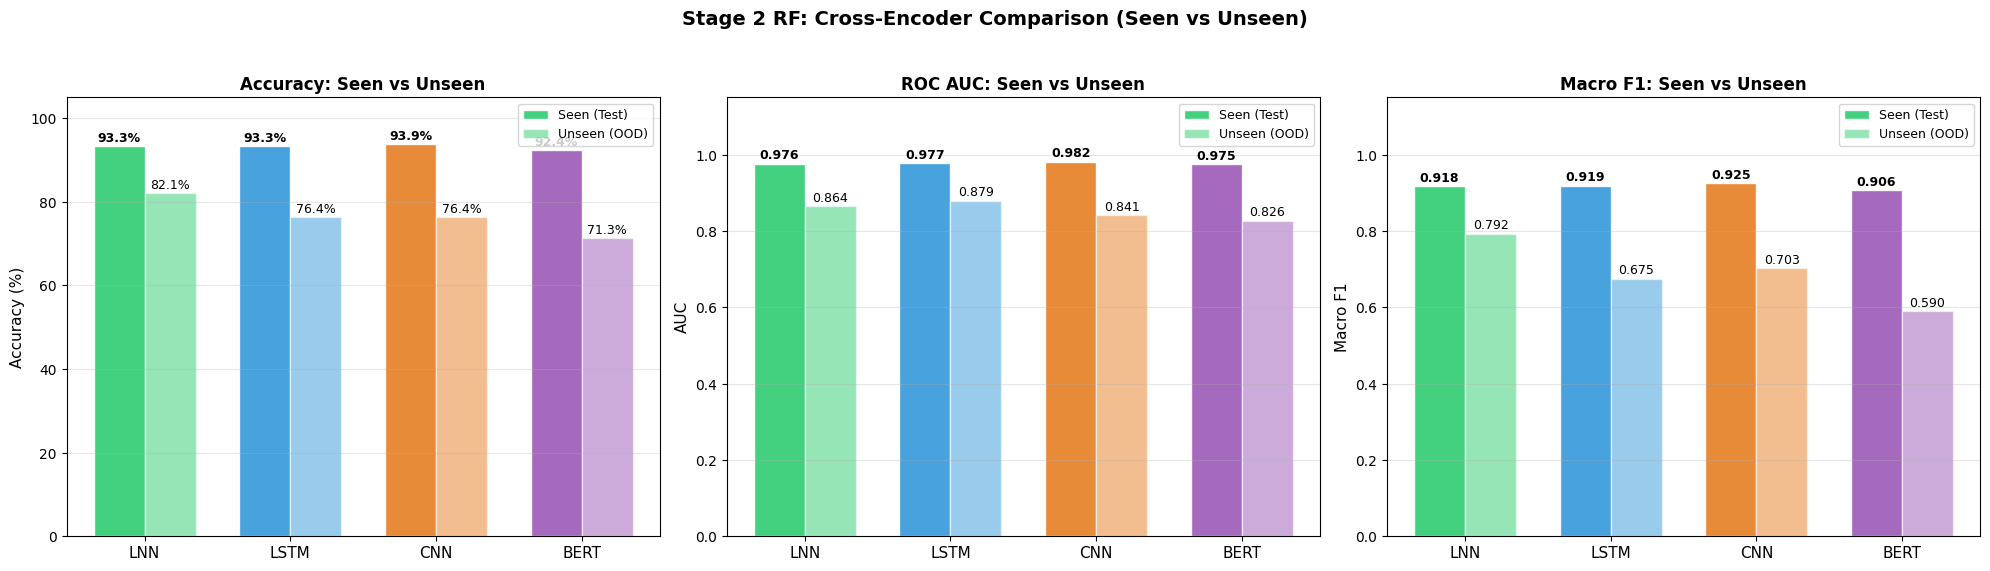

In [28]:
# ==========================================
# BAR CHARTS — ACCURACY & AUC (Seen vs Unseen)
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(20, 5.5))

x = np.arange(len(encoder_names))
w = 0.35
c_seen = [colors[n] for n in encoder_names]

# Plot 1: Accuracy
ax = axs[0]
seen_accs = [100*rf_results[n]['seen_acc'] for n in encoder_names]
unseen_accs = [100*rf_results[n]['unseen_acc'] for n in encoder_names]
bars1 = ax.bar(x - w/2, seen_accs, w, label='Seen (Test)', color=c_seen, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_accs, w, label='Unseen (OOD)', color=c_seen, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, seen_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unseen_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(encoder_names, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy: Seen vs Unseen', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

# Plot 2: AUC
ax = axs[1]
seen_aucs = [rf_results[n]['seen_auc'] for n in encoder_names]
unseen_aucs = [rf_results[n]['unseen_auc'] for n in encoder_names]
bars1 = ax.bar(x - w/2, seen_aucs, w, label='Seen (Test)', color=c_seen, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_aucs, w, label='Unseen (OOD)', color=c_seen, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, seen_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unseen_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(encoder_names, fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('ROC AUC: Seen vs Unseen', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.15)

# Plot 3: Macro F1
ax = axs[2]
seen_f1m = [rf_results[n]['seen_report']['macro avg']['f1-score'] for n in encoder_names]
unseen_f1m = [rf_results[n]['unseen_report']['macro avg']['f1-score'] for n in encoder_names]
bars1 = ax.bar(x - w/2, seen_f1m, w, label='Seen (Test)', color=c_seen, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_f1m, w, label='Unseen (OOD)', color=c_seen, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, seen_f1m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unseen_f1m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(encoder_names, fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Macro F1: Seen vs Unseen', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.15)

plt.suptitle('Stage 2 RF: Cross-Encoder Comparison (Seen vs Unseen)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 10. Full Classification Reports (Printable)

In [29]:
# ==========================================
# FULL CLASSIFICATION REPORTS — FOR COPY-PASTE TO REPORT
# ==========================================
for name in encoder_names:
    r = rf_results[name]
    print(f"\n{'='*70}")
    print(f"{name} Embedded ({r['emb_dim']}-dim) + RF — SEEN (Test Split)")
    print(f"{'='*70}")
    print(f"Accuracy: {100*r['seen_acc']:.2f}%")
    print(f"ROC AUC:  {r['seen_auc']:.4f}")
    print(f"Avg Precision (AP): {r['seen_ap']:.4f}")
    print()
    print(classification_report(y_test, r['seen_pred'],
                                 target_names=['Correctable', 'Challenging']))
    print("Per-scenario accuracy:")
    for sc in unique_scenarios:
        acc = r['seen_per_scenario'].get(sc, 0)
        print(f"  {sc:>8s} NLOS: {100*acc:.1f}%")
    
    print(f"\n{'-'*70}")
    print(f"{name} Embedded ({r['emb_dim']}-dim) + RF — UNSEEN (OOD)")
    print(f"{'-'*70}")
    print(f"Accuracy: {100*r['unseen_acc']:.2f}%")
    print(f"ROC AUC:  {r['unseen_auc']:.4f}")
    print(f"Avg Precision (AP): {r['unseen_ap']:.4f}")
    print()
    print(classification_report(unseen_labels, r['unseen_pred'],
                                 target_names=['Correctable', 'Challenging']))
    print("Per-scenario accuracy:")
    for sc in unseen_unique_scenarios:
        acc = r['unseen_per_scenario'].get(sc, 0)
        print(f"  {sc:>8s} NLOS: {100*acc:.1f}%")


LNN Embedded (64-dim) + RF — SEEN (Test Split)
Accuracy: 93.33%
ROC AUC:  0.9762
Avg Precision (AP): 0.9912

              precision    recall  f1-score   support

 Correctable       0.88      0.88      0.88       152
 Challenging       0.95      0.95      0.95       388

    accuracy                           0.93       540
   macro avg       0.92      0.92      0.92       540
weighted avg       0.93      0.93      0.93       540

Per-scenario accuracy:
     9.54m NLOS: 92.7%
    16.09m NLOS: 88.4%
    16.80m NLOS: 100.0%

----------------------------------------------------------------------
LNN Embedded (64-dim) + RF — UNSEEN (OOD)
----------------------------------------------------------------------
Accuracy: 82.08%
ROC AUC:  0.8641
Avg Precision (AP): 0.9112

              precision    recall  f1-score   support

 Correctable       0.77      0.67      0.72       406
 Challenging       0.84      0.90      0.87       794

    accuracy                           0.82      1200
   ma

---
## 11. Per-Scenario Accuracy Bar Charts

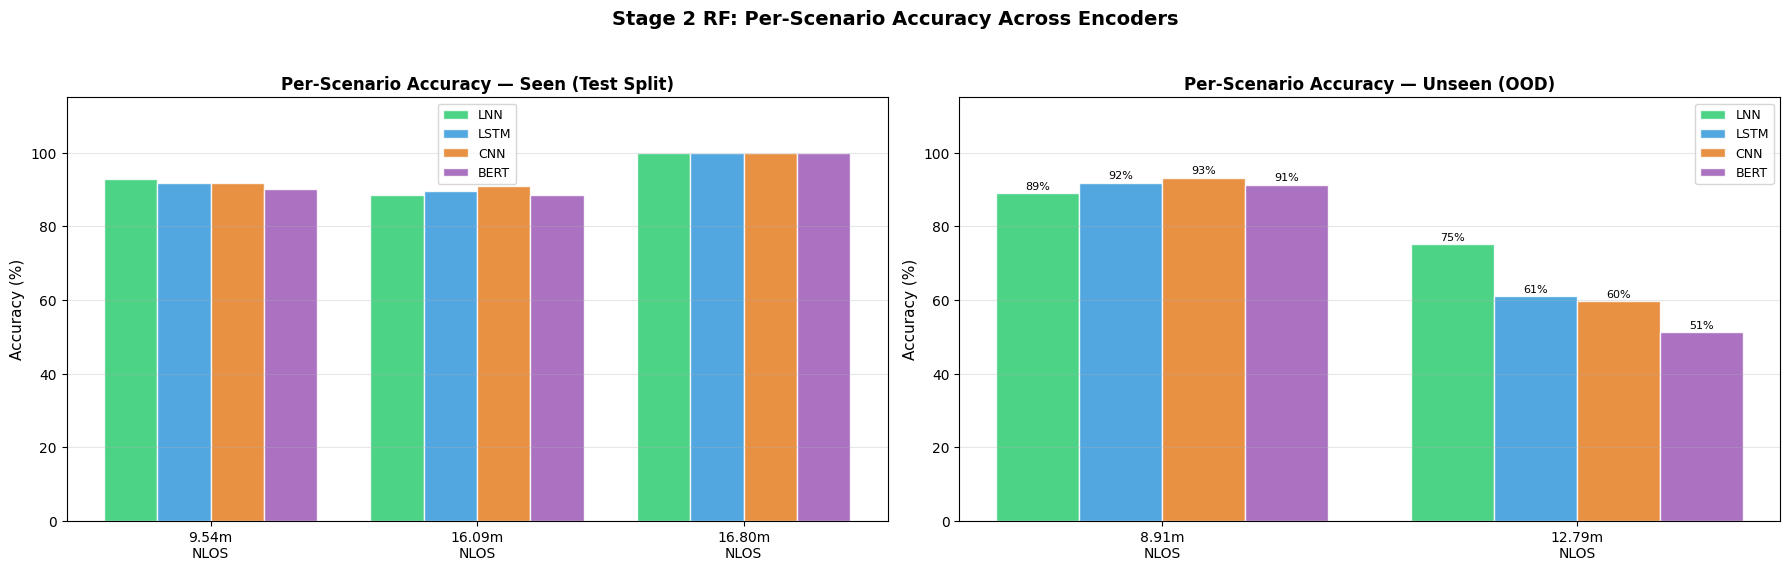

In [30]:
# ==========================================
# PER-SCENARIO ACCURACY — SEEN + UNSEEN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5))

# Seen scenarios
n_sc = len(unique_scenarios)
n_enc = len(encoder_names)
x_sc = np.arange(n_sc)
bw = 0.8 / n_enc

for idx, name in enumerate(encoder_names):
    accs = [100*rf_results[name]['seen_per_scenario'].get(sc, 0) for sc in unique_scenarios]
    offset = (idx - n_enc/2 + 0.5) * bw
    ax1.bar(x_sc + offset, accs, bw, label=name, color=colors[name], alpha=0.85, edgecolor='white')
ax1.set_xticks(x_sc)
ax1.set_xticklabels([f"{s}\nNLOS" for s in unique_scenarios], fontsize=10)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Per-Scenario Accuracy — Seen (Test Split)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 115)

# Unseen scenarios
n_sc_u = len(unseen_unique_scenarios)
x_sc_u = np.arange(n_sc_u)

for idx, name in enumerate(encoder_names):
    accs = [100*rf_results[name]['unseen_per_scenario'].get(sc, 0) for sc in unseen_unique_scenarios]
    offset = (idx - n_enc/2 + 0.5) * bw
    bars = ax2.bar(x_sc_u + offset, accs, bw, label=name, color=colors[name], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, accs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x_sc_u)
ax2.set_xticklabels([f"{s}\nNLOS" for s in unseen_unique_scenarios], fontsize=10)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Per-Scenario Accuracy — Unseen (OOD)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 115)

plt.suptitle('Stage 2 RF: Per-Scenario Accuracy Across Encoders',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 12. Feature Importance (Top 15 per Encoder)

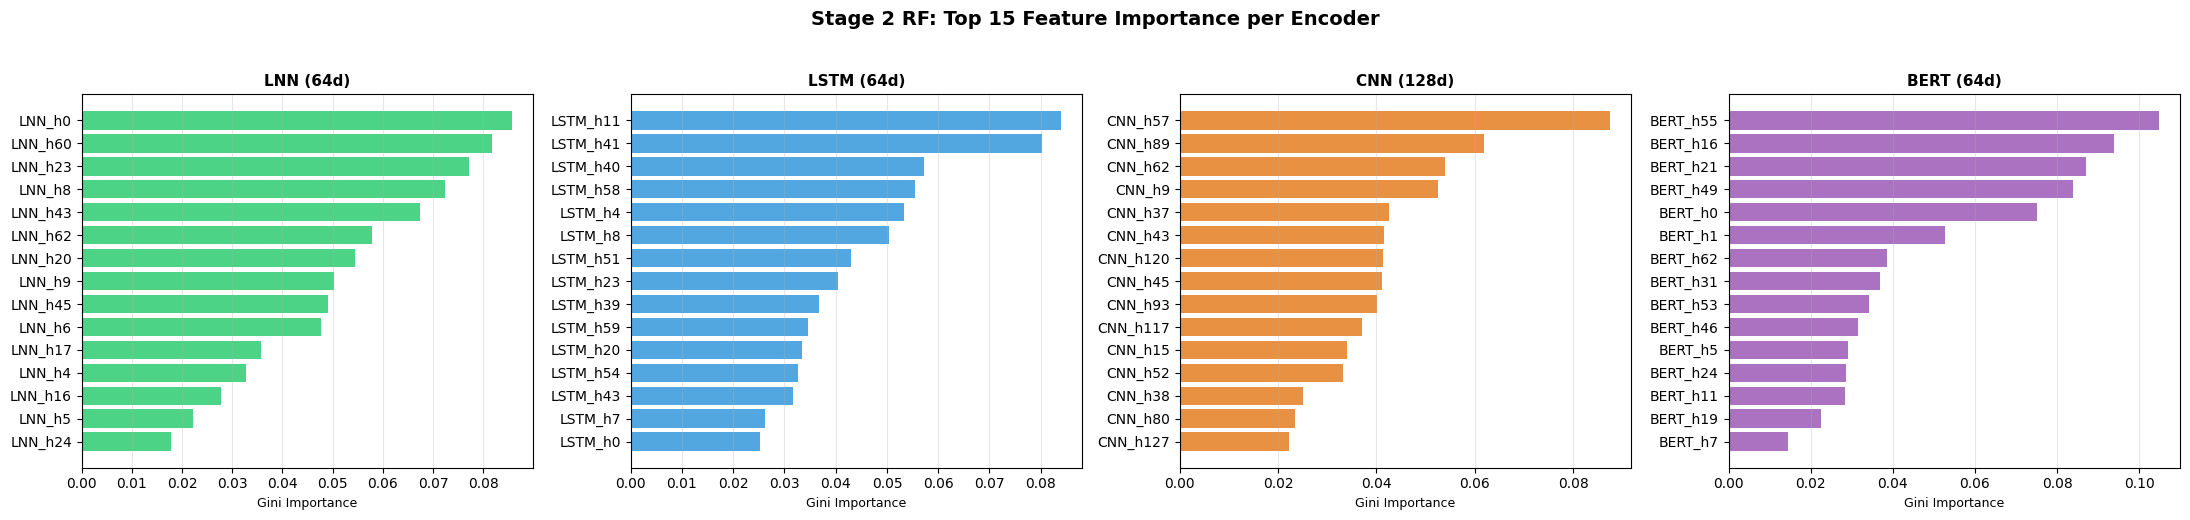

In [31]:
# ==========================================
# RF FEATURE IMPORTANCE — TOP 15 PER ENCODER
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(22, 5))

for idx, name in enumerate(encoder_names):
    ax = axs[idx]
    r = rf_results[name]
    importances = r['rf_model'].feature_importances_
    feat_names = [f'{name}_h{i}' for i in range(r['emb_dim'])]
    top_k = 15
    sorted_idx = np.argsort(importances)[-top_k:]
    ax.barh(np.array(feat_names)[sorted_idx], importances[sorted_idx], color=colors[name], alpha=0.85)
    ax.set_title(f"{name} ({r['emb_dim']}d)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Gini Importance', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Stage 2 RF: Top 15 Feature Importance per Encoder',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 13. Calibration Curves — Seen vs Unseen

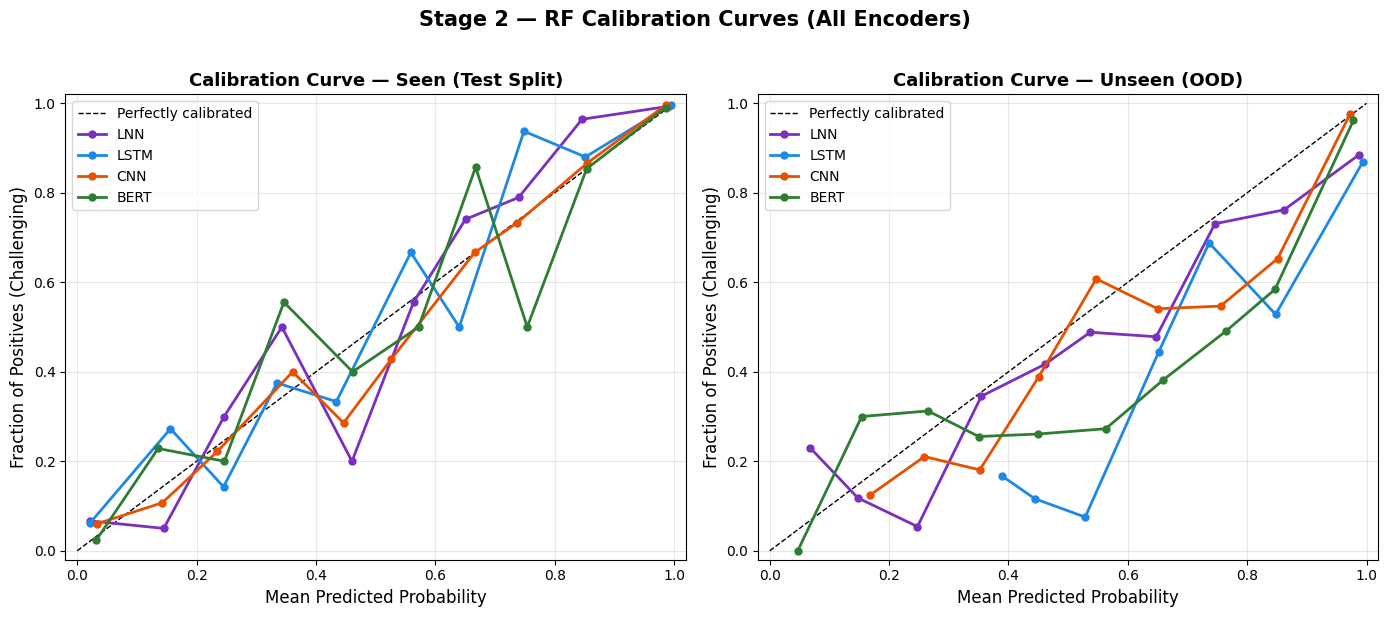

Saved: fig_stage2_calibration_curves.png


In [32]:
# ==========================================
# CALIBRATION CURVES — SEEN vs UNSEEN
# ==========================================
from sklearn.calibration import calibration_curve

encoder_names = ["LNN", "LSTM", "CNN", "BERT"]
colors = {"LNN": "#7B2FBE", "LSTM": "#1E88E5", "CNN": "#E65100", "BERT": "#2E7D32"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, split, prob_key, y_true in [
    (axes[0], "Seen (Test Split)", "seen_prob", y_test),
    (axes[1], "Unseen (OOD)", "unseen_prob", unseen_labels),
]:
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfectly calibrated")
    for name in encoder_names:
        prob = rf_results[name][prob_key]
        fraction_pos, mean_pred = calibration_curve(y_true, prob, n_bins=10, strategy="uniform")
        ax.plot(mean_pred, fraction_pos, "o-", color=colors[name], label=name, lw=2, markersize=5)
    ax.set_xlabel("Mean Predicted Probability", fontsize=12)
    ax.set_ylabel("Fraction of Positives (Challenging)", fontsize=12)
    ax.set_title(f"Calibration Curve — {split}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

fig.suptitle("Stage 2 — RF Calibration Curves (All Encoders)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_stage2_calibration_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_stage2_calibration_curves.png")

---
## 14. Per-Scenario Accuracy Heatmap

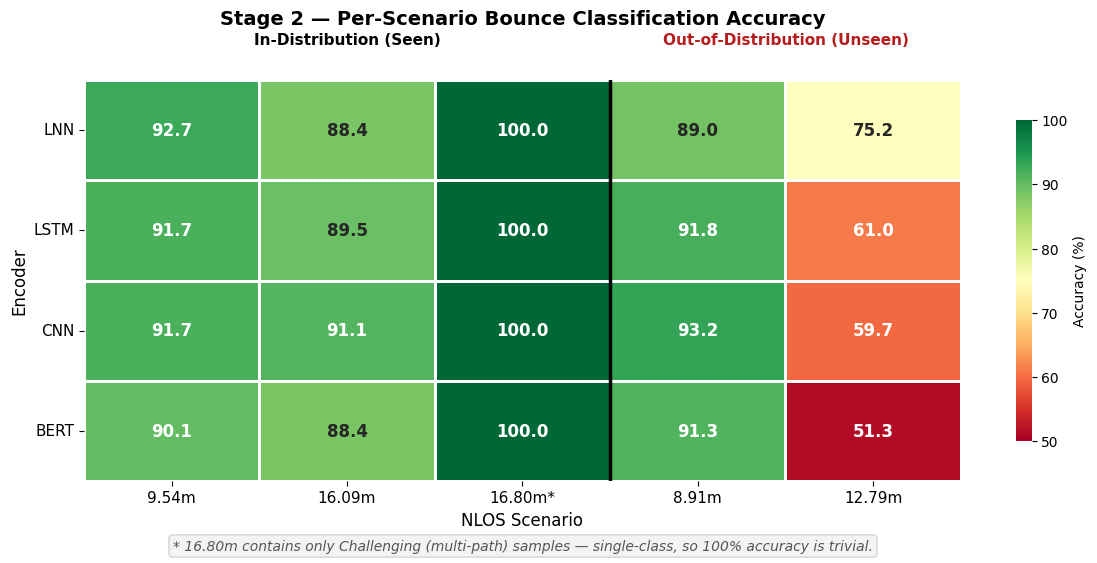

Saved: fig_stage2_scenario_heatmap.png


In [40]:
# ==========================================
# PER-SCENARIO ACCURACY HEATMAP — ALL ENCODERS
# ==========================================
encoder_names = ["LNN", "LSTM", "CNN", "BERT"]

# Collect all scenarios (seen + unseen) in order
seen_scenarios = sorted(set(scenario_labels), key=lambda x: float(x.replace('m','')))
unseen_scens = sorted(set(unseen_scenarios), key=lambda x: float(x.replace('m','')))
all_scenarios = seen_scenarios + unseen_scens

# Column labels — mark trivial scenario
col_labels = [f"{sc}*" if sc == "16.80m" else sc for sc in all_scenarios]

# Build heatmap matrix
heatmap_data = []
for name in encoder_names:
    row = []
    for sc in seen_scenarios:
        row.append(rf_results[name]["seen_per_scenario"].get(sc, np.nan) * 100)
    for sc in unseen_scens:
        row.append(rf_results[name]["unseen_per_scenario"].get(sc, np.nan) * 100)
    heatmap_data.append(row)

df_heat = pd.DataFrame(heatmap_data, index=encoder_names, columns=col_labels)

# Plot
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="RdYlGn", vmin=50, vmax=100,
            linewidths=1, linecolor="white", cbar_kws={"label": "Accuracy (%)", "shrink": 0.8},
            ax=ax, annot_kws={"fontsize": 12, "fontweight": "bold"})

# Add vertical separator between seen and unseen
n_seen = len(seen_scenarios)
ax.axvline(x=n_seen, color="black", lw=2.5)

# Distribution labels above the heatmap columns
ax.text(n_seen / 2, -0.35, "In-Distribution (Seen)", ha="center", fontsize=11, fontweight="bold")
ax.text(n_seen + len(unseen_scens) / 2, -0.35, "Out-of-Distribution (Unseen)",
        ha="center", fontsize=11, fontweight="bold", color="#B71C1C")

ax.set_xlabel("NLOS Scenario", fontsize=12)
ax.set_ylabel("Encoder", fontsize=12)
ax.set_title("Stage 2 — Per-Scenario Bounce Classification Accuracy",
             fontsize=14, fontweight="bold", pad=40)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)

# Footnote — centered below x-axis label
fig.text(0.44, -0.01,
         "* 16.80m contains only Challenging (multi-path) samples — single-class, so 100% accuracy is trivial.",
         ha="center", fontsize=10, fontstyle="italic", color="#555555",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", edgecolor="#cccccc", alpha=0.8))

plt.tight_layout()
plt.savefig("fig_stage2_scenario_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_stage2_scenario_heatmap.png")

---
## Summary

This notebook contains all Stage 2 RF classifier metrics across all 4 encoder architectures.

**Sections for report reference:**
- Table 1: Overall metrics (Acc, AUC, AP, F1) for seen and unseen
- Table 2-3: Per-class precision/recall/F1
- Table 4: Per-scenario accuracy breakdown
- Table 5: Generalization gap
- Plots: Confusion matrices, ROC curves, PR curves, bar charts, feature importance